# MLB Player Data Analysis
### By Marioni Curlango


## Introduction

This project analyzes MLB players' physical characteristics such as age, height, and weight to identify patterns and relationships.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mlb_players.csv", engine="python", on_bad_lines="skip")

df.head()

,Name,"""Team""","""Position""","""Height(inches)""","""Weight(lbs)""","""Age"""
0,Adam Donachie,"""BAL""","""Catcher""",74,180,22.99
1,Paul Bako,"""BAL""","""Catcher""",74,215,34.69
2,Ramon Hernandez,"""BAL""","""Catcher""",72,210,30.78
3,Kevin Millar,"""BAL""","""First Baseman""",72,210,35.43
4,Chris Gomez,"""BAL""","""First Baseman""",73,188,35.71


## Data Cleaning

The dataset contained formatting issues and non-numeric values. The following steps were applied:

- Removed quotation marks from column names
- Converted weight to numeric values
- Removed missing values


In [66]:
df.columns = df.columns.str.replace('"', '').str.strip()

df["Weight(lbs)"] = pd.to_numeric(df["Weight(lbs)"], errors="coerce")
df.columns = df.columns.str.replace('"', '').str.strip()
df = df.dropna(subset=["Weight(lbs)"])

## Age Analysis

- Average age: 28.7 years
- Most players are between 24–30 years old

This suggests that MLB players are typically in their peak performance stage, combining physical ability and experience.

In [79]:
df["Age"].mean()

np.float64(28.73764762826718)

## Top 5 Oldest Players

In [80]:
df.sort_values("Age", ascending=False).head(5)

,Name,Team,Position,Height(inches),Weight(lbs),Age
690,Julio Franco,"""NYM""","""First Baseman""",73,188.0,48.52
814,Jamie Moyer,"""PHI""","""Starting Pitcher""",72,175.0,44.28
573,Randy Johnson,"""ARZ""","""Starting Pitcher""",82,231.0,43.47
982,Barry Bonds,"""SF""","""Outfielder""",74,228.0,42.60
170,Roberto Hernandez,"""CLE""","""Relief Pitcher""",76,250.0,42.30


## Top 5 Youngest Players

In [82]:
df.sort_values("Age", ascending=True).head(5)

,Name,Team,Position,Height(inches),Weight(lbs),Age
296,Felix Hernandez,"""SEA""","""Starting Pitcher""",75,225.0,20.90
326,Delmon Young,"""TB""","""Outfielder""",75,205.0,21.46
297,Ryan Feierabend,"""SEA""","""Starting Pitcher""",75,190.0,21.52
293,Adam Jones,"""SEA""","""Outfielder""",74,200.0,21.58
275,Andrew Miller,"""DET""","""Relief Pitcher""",78,210.0,21.78


## Top 5 Heaviest Players

In [74]:
df.sort_values("Weight(lbs)", ascending=False).head(5)

,Name,Team,Position,Height(inches),Weight(lbs),Age
159,C.C. Sabathia,"""CLE""","""Starting Pitcher""",79,290.0,26.61
236,Chris Britton,"""NYY""","""Relief Pitcher""",75,278.0,24.21
430,Frank Thomas,"""TOR""","""Designated Hitter""",77,275.0,38.76
64,Bobby Jenks,"""CWS""","""Relief Pitcher""",75,270.0,25.96
833,Prince Fielder,"""MLW""","""First Baseman""",72,260.0,22.81


## Top 5 Tallest Players

In [71]:
df.sort_values("Height(inches)", ascending=False).head(5)

,Name,Team,Position,Height(inches),Weight(lbs),Age
928,Jon Rauch,"""WAS""","""Relief Pitcher""",83,260.0,28.42
573,Randy Johnson,"""ARZ""","""Starting Pitcher""",82,231.0,43.47
881,Chris Young,"""SD""","""Starting Pitcher""",82,250.0,27.77
62,Andrew Sisco,"""CWS""","""Relief Pitcher""",81,260.0,24.13
781,Mark Hendrickson,"""LA""","""Starting Pitcher""",81,230.0,32.69


## Height Analysis by Position

In [73]:
df.groupby("Position")["Height(inches)"].mean().sort_values(ascending=False)

Position
"Starting Pitcher"     74.731818
"Relief Pitcher"       74.374603
"Designated Hitter"    74.222222
"First Baseman"        74.000000
"Third Baseman"        73.044444
"Outfielder"           73.010309
"Catcher"              72.723684
"Shortstop"            71.903846
"Second Baseman"       71.362069
Name: Height(inches), dtype: float64

## Weight Analysis by Position

In [58]:
df.groupby("Position")["Weight(lbs)"].mean().sort_values(ascending=False)

Position
"Designated Hitter"    220.888889
"First Baseman"        213.109091
"Starting Pitcher"     205.163636
"Catcher"              204.328947
"Relief Pitcher"       203.517460
"Third Baseman"        200.955556
"Outfielder"           199.113402
"Second Baseman"       184.344828
"Shortstop"            182.923077
Name: Weight(lbs), dtype: float64

## Height vs Weight Relationship

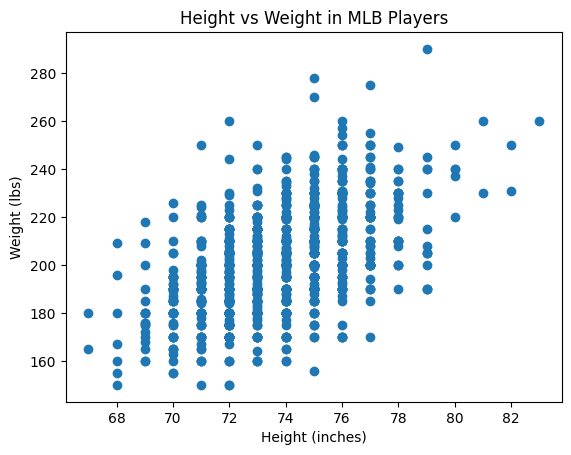

In [59]:
import matplotlib.pyplot as plt

plt.scatter(df["Height(inches)"], df["Weight(lbs)"])
plt.xlabel("Height (inches)")
plt.ylabel("Weight (lbs)")
plt.title("Height vs Weight in MLB Players")
plt.show()

## Age and Weight Relationship

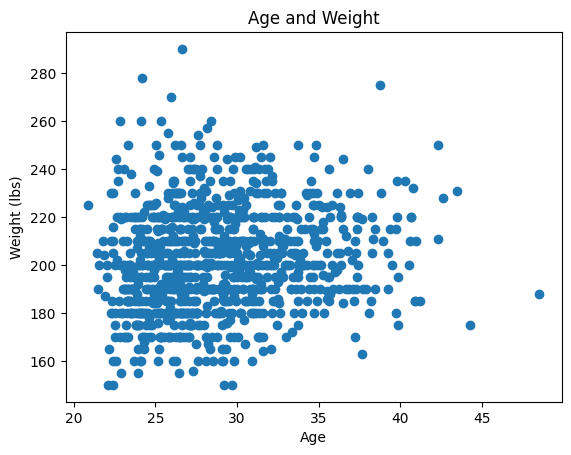

In [87]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Weight(lbs)"])
plt.xlabel("Age")
plt.ylabel("Weight (lbs)")
plt.title("Age and Weight")
plt.show()

## Age and Height Relationship

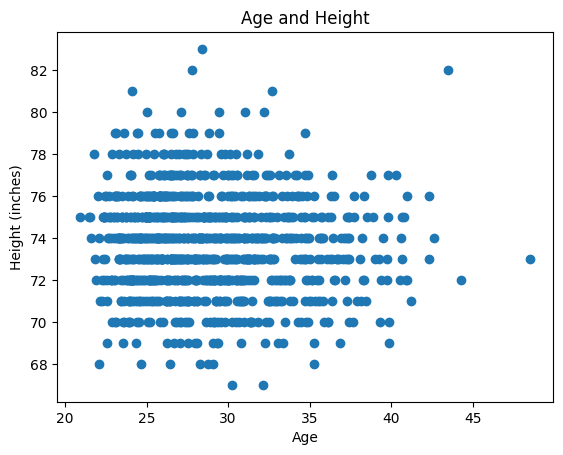

In [92]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Height(inches)"])
plt.xlabel("Age")
plt.ylabel("Height (inches)")
plt.title("Age and Height")
plt.show()

## Correlation Analysis

- Age vs Height: no significant relationship
- Age vs Weight: very weak relationship
- Height vs Weight: moderate positive relationship

This indicates that height is a better predictor of weight than age.

In [93]:
df[["Age", "Height(inches)", "Weight(lbs)"]].corr()

,Age,Height(inches),Weight(lbs)
Age,1.000000,-0.073851,0.158282
Height(inches),-0.073851,1.000000,0.531886
Weight(lbs),0.158282,0.531886,1.000000


## Data Visualization

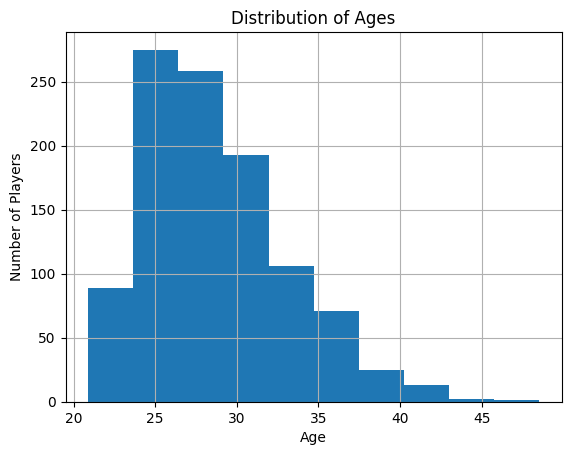

In [94]:
df["Age"].hist(bins=10)
plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

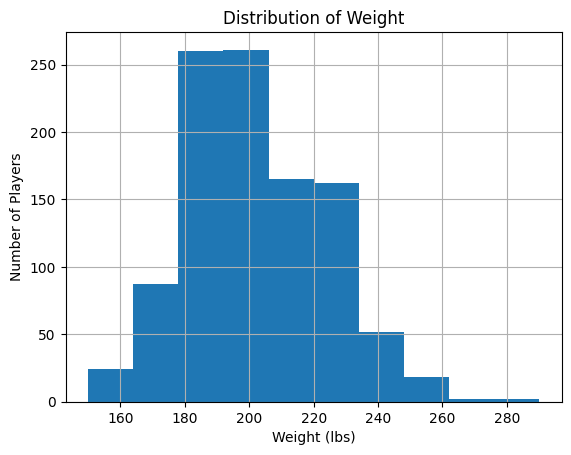

In [95]:
df["Weight(lbs)"].hist(bins=10)
plt.title("Distribution of Weight")
plt.xlabel("Weight (lbs)")
plt.ylabel("Number of Players")
plt.show()

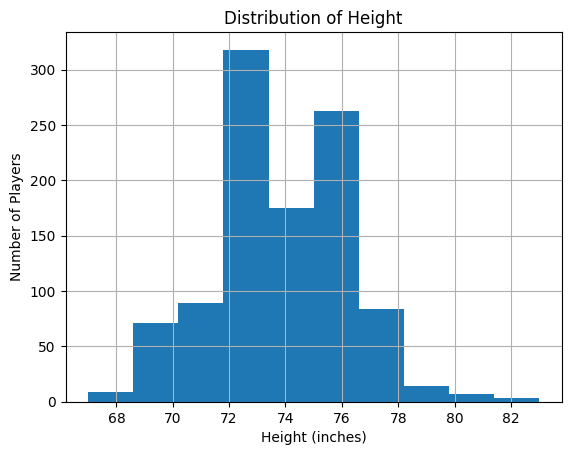

In [96]:
df["Height(inches)"].hist(bins=10)
plt.title("Distribution of Height")
plt.xlabel("Height (inches)")
plt.ylabel("Number of Players")
plt.show()

## Limitations

The dataset appears to be outdated, as some players are no longer active. However, it still provides useful insights into general player characteristics.

## Conclusion

This analysis of MLB player data reveals clear patterns in physical characteristics such as age, height, and weight.

Most players are concentrated between 24 and 30 years old, with an average age of approximately 28.7. This suggests that MLB players are typically in their peak performance stage, where physical ability and experience are balanced.

In terms of weight, the majority of players fall within the range of 180 to 205 lbs, indicating a consistent athletic build across the league. While some players fall outside this range, they represent exceptions rather than the norm.

Height is also relatively consistent, with most players measuring between 72 and 76 inches. This suggests that there is an optimal height range that is common among professional players.

The correlation analysis shows that age has little to no relationship with height or weight, meaning that physical characteristics remain relatively stable across different ages. In contrast, height and weight show a moderate positive correlation, indicating that taller players tend to weigh more.

Additionally, differences between positions highlight how physical attributes vary depending on player roles. For example, pitchers tend to be taller, while positions such as shortstop and second baseman are generally lighter.

Although the dataset appears to be outdated, it still provides valuable insights into general trends and relationships among MLB players.

Overall, this project demonstrates how data analysis and visualization can be used to identify meaningful patterns in sports performance and player characteristics.